In [1]:
import torch
from torch.utils.data import DataLoader
from torch import nn
import torch.optim as optim
import torchvision.models as models

import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'functions')))
from dataset import ChestXrayDataset
from train import train
from evaluation import plot_results ,eval_on_metrics
from gradcam import get_heatmap_for_resnet

In [2]:
IMAGE_PATH = "../archive/"
import glob

# Tüm alt klasörlerdeki jpg ve png dosyalarını alalım
image_paths = glob.glob(IMAGE_PATH + "**/images/*.[jp][pn]g", recursive=True)

print(f"Toplam {len(image_paths)} resim bulundu.")

Toplam 112120 resim bulundu.


In [3]:
TRAIN_PATH = '../data/AP_PA_Train.xlsx'
TEST_PATH = '../data/AP_PA_Test.xlsx'
VAL_PATH = '../data/AP_PA_Validation.xlsx'

In [4]:
num_classes = 2
EPOCHS = 30

In [5]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [7]:
train_dataset = ChestXrayDataset(TRAIN_PATH, image_paths,transform=transform)
val_dataset = ChestXrayDataset(TEST_PATH,image_paths, transform=transform)
test_dataset = ChestXrayDataset(VAL_PATH,image_paths, transform=transform)
print("Train size : ",len(train_dataset))
print("Validation size : ",len(val_dataset))
print("Test size : ",len(test_dataset))

Train size :  78566
Validation size :  16491
Test size :  17063


In [9]:
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True,num_workers=18, pin_memory=True)
val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=False,num_workers=18, pin_memory=True)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False,num_workers=10)

In [16]:
from fastai.data.core import DataLoaders

dls = DataLoaders(train_dataloader, val_dataloader)
dls.c = 2

In [19]:
from fastai.vision.all import *

learn = Learner(dls, resnet50(num_classes=num_classes), 
                loss_func=nn.CrossEntropyLoss(), 
                metrics=accuracy)
learn.fit_one_cycle(3)
 

epoch,train_loss,valid_loss,accuracy,time
0,0.057551,0.064103,0.982657,05:44
1,0.026816,0.045605,0.987812,05:46
2,0.017238,0.021605,0.994724,05:49


Precision: 0.9949
Recall:    0.9969
F1 Score:  0.9959
AUC:       0.9991


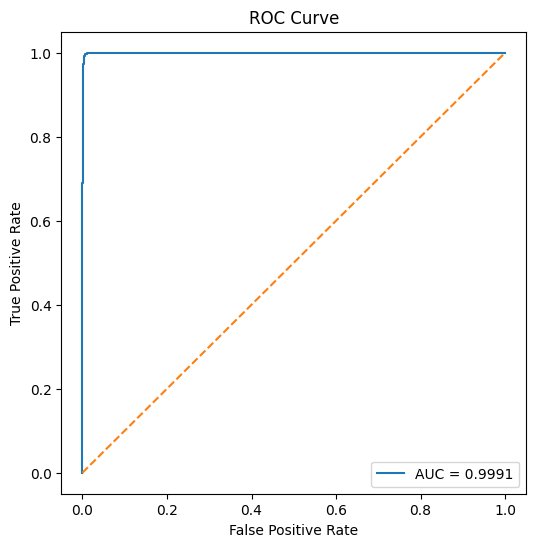

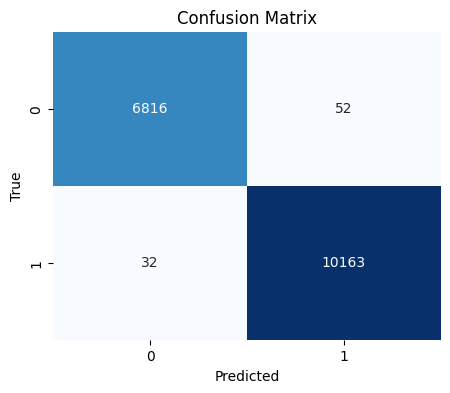

In [20]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
preds, targs = learn.get_preds(dl=test_dataloader)
pred_classes = preds.argmax(dim=1)

y_true = targs.numpy()
y_pred = pred_classes.numpy()
y_scores = preds[:,1].numpy()  # pozitif sınıf olasılığı

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC:       {roc_auc:.4f}")

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


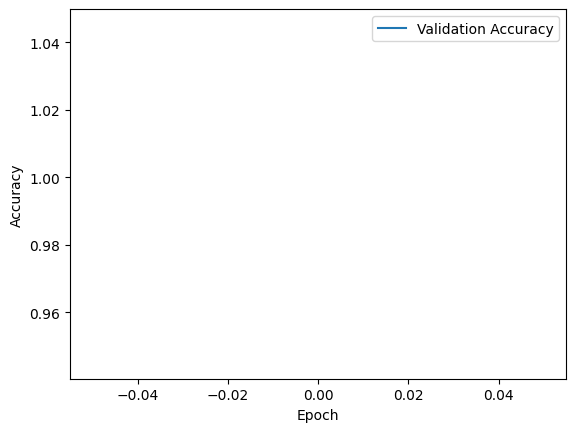

In [21]:
train_losses = [x.item() for x in learn.recorder.losses]
# Not: learn.recorder.losses, batch bazında kayıp tutar, epoch bazında değil
val_losses = learn.recorder.values
val_accuracies = [x[1] for x in val_losses]  # validasyon accuracy sütunu (genelde 2. sütun)

# epoch sayısı
epochs = len(val_accuracies)

# Örnek çizim (train loss yerine validasyon kaybı çizilebilir)
plt.plot(range(epochs), val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()